In [112]:
import numpy as np
import yfinance as yf
import sympy as sp
import datetime as dt
import pandas as pd

def Phi(x): return 1/2*(sp.erf(x/sp.sqrt(2))+1)
def Phiinv(x): return sp.sqrt(2)*sp.erfinv(2*x-1)
def phi(x): return 1/sp.sqrt(2*sp.pi)*sp.exp(-x**2/2)

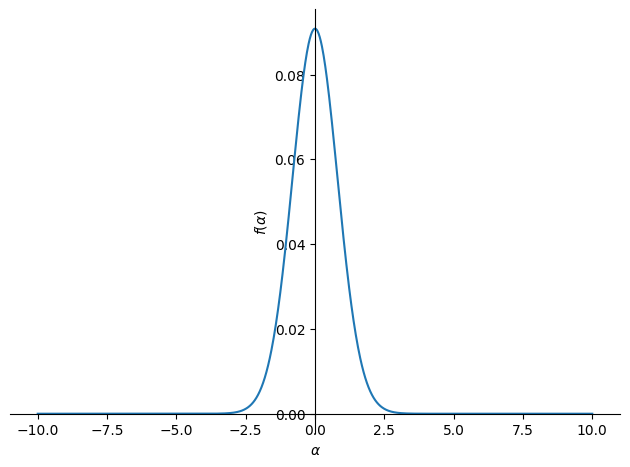

In [113]:
a = sp.Symbol('alpha')

mu = a*Phi(a) + phi(a)
sigma = Phi(a)*a**2*(1-Phi(a)) + phi(a)*(a-2*a*Phi(a)-phi(a)) - Phi(a)+1

D = Phi(a)*a**2*(1-Phi(a)) + phi(a)*(a-2*a*Phi(a)-phi(a)) + Phi(a) - Phi(a)**2

sp.plot(D)

In [ ]:
Zs = -2
Ze = -Zs

als = np.linspace(Zs, Ze, int(Ze-Zs)*100+1)
sigmas = np.array([float(sigma.subs(a, al).evalf()) for al in als])
mus = np.array([float(mu.subs(a, al).evalf()) for al in als])

In [47]:
import plotly.graph_objects as go

red = '#f8766d'
blue = '#619cff'

style_dict = {
    'layout.plot_bgcolor': 'rgba(0, 0, 0, 0)',
    'layout.font.family': 'Times New Roman',
    'layout.font.size': 18,
    'layout.xaxis.linecolor': 'black',
    'layout.xaxis.ticks': 'inside',
    'layout.xaxis.mirror': True,
    'layout.xaxis.showline': True,
    'layout.yaxis.linecolor': 'black',
    'layout.yaxis.ticks': 'inside',
    'layout.yaxis.mirror': True,
    'layout.yaxis.showline': True,
    'layout.autosize': False,
    'layout.legend.bgcolor': 'rgba(0, 0, 0, 0)',
    'layout.legend.xanchor': 'right',
    'layout.legend.x': 0.25,
    'layout.legend.font.family': 'monospace',
}

fig = go.Figure()

fig.update(**style_dict)

fig.update_layout(height=600, width=800, margin=dict(r=5, l=5, t=5, b=5),
                  xaxis=dict(title=r"$\alpha$"),
                  yaxis=dict(title=r"$\text{Multiple of } \sigma^2$"))

fig.add_trace(go.Scatter(x = als, y = sigmas, name="Sigma", mode='lines'))

fig.write_image("graphs/variance.png", scale=5, height=450, width=800)
fig.show()

fig = go.Figure()

fig.update(**style_dict)

fig.update_layout(height=600, width=800, margin=dict(r=5, l=5, t=5, b=5),
                  xaxis=dict(title=r"$\alpha$"),
                  yaxis=dict(title=r"$\text{Excess returns as multiple of } \sigma$"))

fig.add_trace(go.Scatter(x = als, y = mus, name="Sigma", mode='lines'))

fig.write_image("graphs/expectation.png", scale=5, height=450, width=800)
fig.show()

In [ ]:
import plotly.express as px

n = 51

als_small = np.linspace(-5, 5, n)

a_i, a_j =sp.symbols("a_i, a_j")

a_array = np.array([[(a_i, a_j) for a_j in als_small] for a_i in als_small])



s = {}
cov = {}

counter = 0

for rho in np.linspace(0, 1, 11):
    covar = (1-Phi(a_i))*(1-Phi(a_j))
    covars = np.zeros((n,n))
    
    for i, ali in enumerate(als_small):
        ali = float(ali)
        if i in s:
            si = s[i]
            
        else:
            si = float(sigma.subs(a, ali))
            s[i] = si
        
        for j, alj in enumerate(als_small):
            if i > j: continue
            alj = float(alj)
            if j in s:
                sj = s[j]
            else:
                sj = float(sigma.subs(a, alj))
                s[j] = sj
            
            if (i, j) in cov:
                covij  = cov[(i, j)]
            else:
                covij = covar.subs(a_i, ali).subs(a_j, alj)
                cov[(i, j)] = float(covij)
                
            covars[i, j] = si*sj-rho*covij
            covars[j, i] = si*sj-rho*covij
        
    px.line(x = als_small, y=[[s[(i, i)] for i in range(n)], [covars[(i, i)] for i in range(n)]]).show()
            
    print(f"NUM VALUES WHERE COVAR EXCEEDS sqrt(sigma_i*sigma_j): {len(np.where(covars < 0)[0] + np.where(covars < 0)[1])}")

In [103]:
rho = sp.Symbol('rho')
phi, Phi = sp.symbols('phi, Phi')
alpha = sp.Symbol('alpha')

sigma = Phi*alpha**2*(1-Phi)+phi*(alpha-2*alpha*Phi-phi)-Phi+1

In [ ]:
covar =1-2*Phi+Phi**2

sigma - covar



TypeError: 'Symbol' object is not callable

In [49]:
from sympy.stats import ContinuousRV
from sympy.stats import Normal, density, E, std, cdf, skewness, quantile, marginal_distribution
from sympy import Interval, oo

K = sp.Symbol("K")

pdf = Normal("x", 0, 1)
Y = ContinuousRV(D, pdf, set=Interval(K, oo))


E(Y)

AttributeError: 'Lambda' object has no attribute 'pspace'

In [2]:
import yfinance as yf

yf.Ticker('GOOG').history(period='max')

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2004-08-19 00:00:00-04:00,2.470383,2.570680,2.370580,2.478783,897427216,0.0,0.0
2004-08-20 00:00:00-04:00,2.495333,2.694693,2.482735,2.675672,458857488,0.0,0.0
2004-08-23 00:00:00-04:00,2.735949,2.803391,2.693953,2.702599,366857939,0.0,0.0
2004-08-24 00:00:00-04:00,2.748054,2.756947,2.558575,2.590690,306396159,0.0,0.0
2004-08-25 00:00:00-04:00,2.592913,2.668014,2.566233,2.618605,184645512,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-30 00:00:00-04:00,371.255005,382.630005,363.089996,381.940002,44570500,0.0,0.0
2026-05-01 00:00:00-04:00,377.980011,383.390015,375.260010,383.220001,28047900,0.0,0.0
2026-05-04 00:00:00-04:00,382.320007,384.179993,376.769989,379.640015,18275000,0.0,0.0
